In [1]:
import os
from synth_pat.paths import Paths

RESOURCES_DIR = Paths.RESOURCES
DERIVATIVES_DIR = '/data3/VBT_SCZ/derivatives'

import nibabel as nib
from nilearn import image
from nilearn.signal import clean
from nilearn.input_data import NiftiLabelsMasker

import pandas as pd 
import numpy as np 
import json

import matplotlib.pyplot as plt

/tmp/ipykernel_863868/3633775688.py:10: DeprecationWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiLabelsMasker


In [11]:
from importlib import reload

In [13]:
import postproc_utils 
reload(postproc_utils)

<module 'postproc_utils' from '/data3/VBT_SCZ/scadv/synth_pat/scripts/post_preprocessing/postproc_utils.py'>

## Select confounds columns first

In [3]:
conf_dic= {'mov_only': ['rot_x', 'rot_y', 'rot_z', 'trans_x', 'trans_y', 'trans_z']}
conf_dic1= {'daniela': ['rot_x', 'rot_y', 'rot_z', 'trans_x', 'trans_y', 'trans_z', 'white_matter', 'csf'],
           'mov_comp': ['rot_x', 'rot_y', 'rot_z', 'trans_x', 'trans_y', 'trans_z', 'white_matter', 'c_comp_cor_00', 'c_comp_cor_01', 'w_comp_cor_00'],
           'comp_and_edge': ['white_matter', 'c_comp_cor_00', 'c_comp_cor_01', 'w_comp_cor_00', 'edge_comp_01', 'edge_comp_02', 'edge_comp_09'],
           'traditional': ['global_signal', 'white_matter', 'csf', 'rot_x', 'rot_y', 'rot_z', 'trans_x', 'trans_y', 'trans_z'],
          'muschelli': ['rot_x', 'rot_y', 'rot_z', 'trans_x', 'trans_y', 'trans_z', 
                        'white_matter', 'c_comp_cor_00', 'c_comp_cor_01', 'w_comp_cor_00'],
          'top_muschelli': ['rot_x', 'rot_y', 'rot_z', 'trans_x', 'trans_y', 'trans_z',
                            'c_comp_cor_00', 'w_comp_cor_00', 'edge_comp_00', 'edge_comp_11', 'edge_comp_02', 'white_matter']}

mov_comp put rot and trans plus comp_wc
comp_wc choose based on the correlation (first the best then leave out the high correlated ones)
comp_and_edge based on correlation but include also edge_comp
muschelli put all rot and trans, plus put same comp as comp_wc
top_muschelli put always all rot and trans and add top 6 comp


In [55]:
pid = "sub-1856"
ses = "run-01"
dataset = "rawdata"
RAW_DATA = '/data3/VBT_SCZ/rawdata'
print(f"Searching for {pid} data")
FMRI_DIR = os.path.join(DERIVATIVES_DIR, pid, ses, 'func')
FS_DIR = os.path.join(DERIVATIVES_DIR, 'freesurfer', pid)

#json_file = os.path.join(RAW_DATA, f"{pid}/{ses}/func/{pid}_{ses}_task-rest_bold.json")
end_file = f'{pid}_task-rest_{ses}'
json_file = os.path.join(RAW_DATA, f"{pid}/{ses}/func/{end_file}_bold.json")#
tr = postproc_utils.get_repetition_time(json_file)

# Select the confounds to extract the BOLD time series
confounds_data = pd.read_csv(f"{FMRI_DIR}/{end_file}_desc-confounds_timeseries.tsv", sep='\t')
confounds_json = f"{FMRI_DIR}/{end_file}_desc-confounds_timeseries.json"
bold_file = f"{FMRI_DIR}/{end_file}_space-T1w_desc-preproc_bold.nii.gz"
aparc_file = f"{FS_DIR}/mri/aparc+aseg.nii.gz"

Searching for sub-1856 data


In [56]:
# Define different confound strategies
reload(postproc_utils)
c_comp_cor_50 = postproc_utils.get_combined_top5_compcor(confounds_json)
c_comp_cor_top5, w_comp_cor_top5 = postproc_utils.get_top5_compcor(confounds_json)
motion_correction = ['rot_x', 'rot_y', 'rot_z', 'trans_x', 'trans_y', 'trans_z']
conf_dic = {'daniela': motion_correction + ['white_matter', 'csf'],
            #'traditional': motion_correction + ['global_signal', 'white_matter', 'csf'],
            #'aCompCor': motion_correction + c_comp_cor_top5 + w_comp_cor_top5,
            #'aCompCor50': motion_correction + ['global_signal']
            }

/home/prior/miniconda3/envs/vbt_clinical_env/lib/python3.12/site-packages/sklearn/utils/_set_output.py:316: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.int32(30)}. Label image only contains 108 labels (including background).
  data_to_wrap = f(self, X, *args, **kwargs)


Bold has shape: (240, 107)


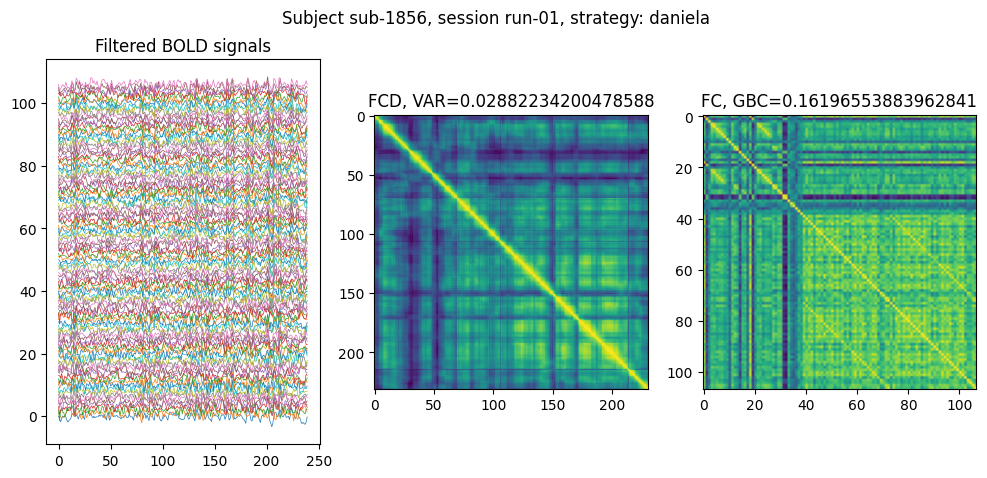

0.3269870312422687


In [ ]:
reload(postproc_utils)
confound = conf_dic
# Load images
bold_img = nib.load(bold_file)
aparc_img = nib.load(aparc_file)
masker = NiftiLabelsMasker(
    labels_img=aparc_img,
    standardize=True,
    detrend=True,
    low_pass=0.198,
    high_pass=0.01,
    t_r=tr
)

fs_def, lut = postproc_utils.read_lut_and_fs_default(atlas='dk')

results = []
emp_bold_path_dict = {}
for combination in conf_dic:
    selected_confunds_columns = conf_dic[combination]
    selected_confunds = confounds_data[selected_confunds_columns]
    time_series = masker.fit_transform(bold_img, confounds=selected_confunds.values)
    print(f"Bold has shape: {time_series.shape}")

    bold_labels = [int(reg) for reg in masker.region_names_.values()]
    lut_bold_labels = lut[lut["Index"].isin(bold_labels)]["FullName"].values
    if lut_bold_labels[0] == 'Unknown': lut_bold_labels = np.delete(lut_bold_labels, 0)
    fs_bold_labels = []
    fs_regs = list(fs_def["FullName"])
    for reg in lut_bold_labels:
        if reg in fs_regs:
            fs_bold_labels.append(fs_def[fs_def["FullName"] == reg]["Abbrev"].item())

    # print(f"Reshaped BOLD has dimension {time_series[:, idx].shape}")

    filtered_bold = time_series#postproc_utils.bandpass_nilearn(time_series, tr=tr)
    #os.makedirs(patient.path_config.pipeline_postproc, exist_ok=True)
    emp_bold_path_dict[combination] = f"{pid}_{ses}_{combination}_filtered_bold.npz"
    np.savez(emp_bold_path_dict[combination], bold=filtered_bold, labels=masker.labels_, TimeRepetition=tr)
    fc, gbc, fcd, var_fcd = postproc_utils.compute_basic_metrics(filtered_bold, tr)
    postproc_utils.plot_signal_and_matrices(pid, ses, combination, filtered_bold, fcd, fc)
    results.append([combination, var_fcd, gbc])

df = pd.DataFrame(data=results, columns=['Strategy', 'VAR_FCD', 'GBC',])
df.to_csv(f"{pid}_{ses}_basic_metrics.csv", index=False)

print(np.mean(fc[np.triu_indices_from(fc, k=1)]))
